# f1 gp
this notebook serves to create the visualizations to populate the articles available in https://f1observatory.blogspot.com/

# import necessary packages

In [1]:
import fastf1
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
from fastf1 import plotting
from fastf1.ergast import Ergast
ERGAST = Ergast()
from pandasql import sqldf
import requests
from fastf1.core import SessionResults

# define variables, dictionaries & dataframes

In [2]:
GP = "Australia"
GP_NAME = "Australian Grand Prix"
SEASON = 2025
ROUND_NUMBER = 1

In [3]:
GRAND_PRIXS = {
    "ROUND": list(range(1, 25)),
    "GRAND_PRIX_NAME": [
        "Bahrain", "Saudi Arabia", "Australia", "Japan", "China",
        "Miami", "Emilia-Romagna", "Monaco", "Canada", "Spain",
        "Austria", "United Kingdom", "Hungary", "Belgium", "Netherlands",
        "Italy", "Azerbaijan", "Singapore", "United States", "Mexico",
        "Brazil", "Las Vegas", "Qatar", "Abu Dhabi"]
    }
GRAND_PRIXS = pd.DataFrame(GRAND_PRIXS)

DRIVERS = ['NOR', 'VER', 'RUS', 'ANT', 'ALB', 'STR', 'HUL', 'LEC', 'PIA', 'HAM', 'GAS', 'TSU', 'OCO', 'BEA', 'LAW', 'BOR', 'ALO', 'SAI', 'DOO', 'HAD']

TEAMS = ['McLaren', 'Red Bull', 'Mercedes', 'Williams', 'Aston Martin', 'Sauber', 'Ferrari', 'Alpine F1 Team', 'RB F1 Team', 'Haas F1 Team']

PALETTE_DRIVERS = {
    'VER': '#0600ef',
    'LAW': '#0600ef',
    'GAS': '#ff87bc',
    'DOO': '#ff87bc',
    'ALO': '#00665f',
    'STR': '#00665f',
    'LEC': '#e8002d',
    'HAM': '#e8002d',
    'SAI': '#00a0dd',
    'ALB': '#00a0dd',
    'OCO': '#b6babd',
    'BEA': '#b6babd',
    'TSU': '#364aa9',
    'HAD': '#364aa9',
    'BOR': '#00e700',
    'HUL': '#00e700',
    'NOR': '#ff8000',
    'PIA': '#ff8000',
    'ANT': '#27f4d2',
    'RUS': '#27f4d2'
    }

DRIVER_STYLES = {
    'VER': 'solid',
    'LAW': 'dashed',
    'GAS': 'solid',
    'DOO': 'dashed',
    'ALO': 'solid',
    'STR': 'dashed',
    'LEC': 'solid',
    'HAM': 'dashed',
    'SAI': 'solid',
    'ALB': 'dashed',
    'OCO': 'solid',
    'BEA': 'dashed',
    'TSU': 'solid',
    'HAD': 'dashed',
    'BOR': 'solid',
    'HUL': 'dashed',
    'NOR': 'solid',
    'PIA': 'dashed',
    'RUS': 'solid',
    'ANT': 'dashed'
    }

PALETTE_TEAMS = {
    'McLaren': '#ff8000',
    'Red Bull': '#0600ef',
    'Mercedes': '#27f4d2',
    'Williams': '#00a0dd',
    'Aston Martin': '#00665f',
    'Sauber': '#00e700',
    'Ferrari': '#e8002d',
    'Alpine F1 Team': '#ff87bc',
    'RB F1 Team': '#364aa9',
    'Haas F1 Team': '#b6babd'
    }

COMPOUND_COLORS = {
    'SOFT': '#da291c',
    'MEDIUM': '#ffd12e',
    'HARD': '#f0f0ec',
    'INTERMEDIATE': '#43b02a',
    'WET': '#0067ad',
    'UNKNOWN': '#00ffff',
    'TEST-UNKNOWN': '#434649'
    }

# the track

In [4]:
SCHEDULE_2024 = ERGAST.get_race_schedule(2024)
ROUND_2024 = sqldf(f"SELECT round FROM SCHEDULE_2024 WHERE raceName = '{GP_NAME}'")
ROUND_2024

req         WARNING 	DEFAULT CACHE ENABLED! (463.68 MB) C:\Users\nb30499\AppData\Local\Temp\fastf1


,round
0,3


core           INFO 	Loading data for Australian Grand Prix - Race [v3.4.4]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['55', '16', '4', '81', '11', '18', '22', '14', '27', '20', '23', '3', '10', '77', '24', '31', '63', '44', '1']


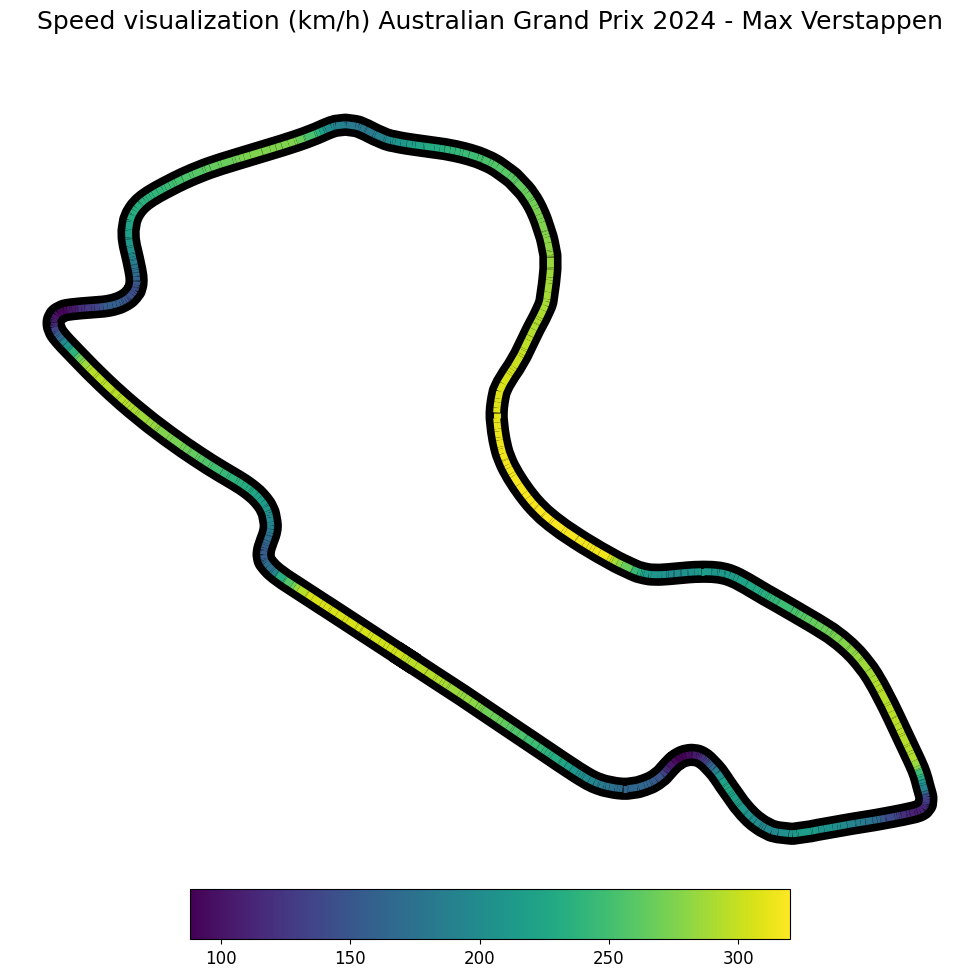

In [5]:
RACE_2024 = fastf1.get_session(SEASON - 1, GP, 'R')
RACE_2024.load()
LAP = RACE_2024.laps.pick_driver("VER").pick_fastest()

X = LAP.telemetry["X"]
Y = LAP.telemetry["Y"]
COLOR = LAP.telemetry["Speed"]
COLORMAP = mpl.cm.viridis

POINTS = np.array([X, Y]).T.reshape(-1, 1, 2)
SEGMENTS = np.concatenate([POINTS[:-1], POINTS[1:]], axis=1)

plt.style.use('default')
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(sharex=True, sharey=True, figsize=(12, 10))
fig.suptitle(f"Speed visualization (km/h) {GP_NAME} 2024 - Max Verstappen", size=18)

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.12)
ax.axis('off')

ax.plot(LAP.telemetry['X'], LAP.telemetry['Y'], color='black', linestyle='-', linewidth=16, zorder=0)

norm = plt.Normalize(COLOR.min(), COLOR.max())
lc = LineCollection(SEGMENTS, cmap=COLORMAP, norm=norm, linestyle='-', linewidth=5)

lc.set_array(COLOR)

line = ax.add_collection(lc)

cbaxes = fig.add_axes([0.25, 0.05, 0.5, 0.05])
normlegend = mpl.colors.Normalize(vmin=COLOR.min(), vmax=COLOR.max())
legend = mpl.colorbar.ColorbarBase(cbaxes, norm=normlegend, cmap=COLORMAP, orientation="horizontal")

plt.show()

# load GP events

In [6]:
FP1 = fastf1.get_session(SEASON, GP, 'FP1')
FP1.load()
FP2 = fastf1.get_session(SEASON, GP, 'FP2')
FP2.load()
FP3 = fastf1.get_session(SEASON, GP, 'FP3')
FP3.load()
Q = fastf1.get_session(SEASON, GP, 'Q')
Q.load()
RACE = fastf1.get_session(SEASON, GP, 'R')
RACE.load()

core           INFO 	Loading data for Australian Grand Prix - Practice 1 [v3.4.4]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '7', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '63', '81', 

# free practices

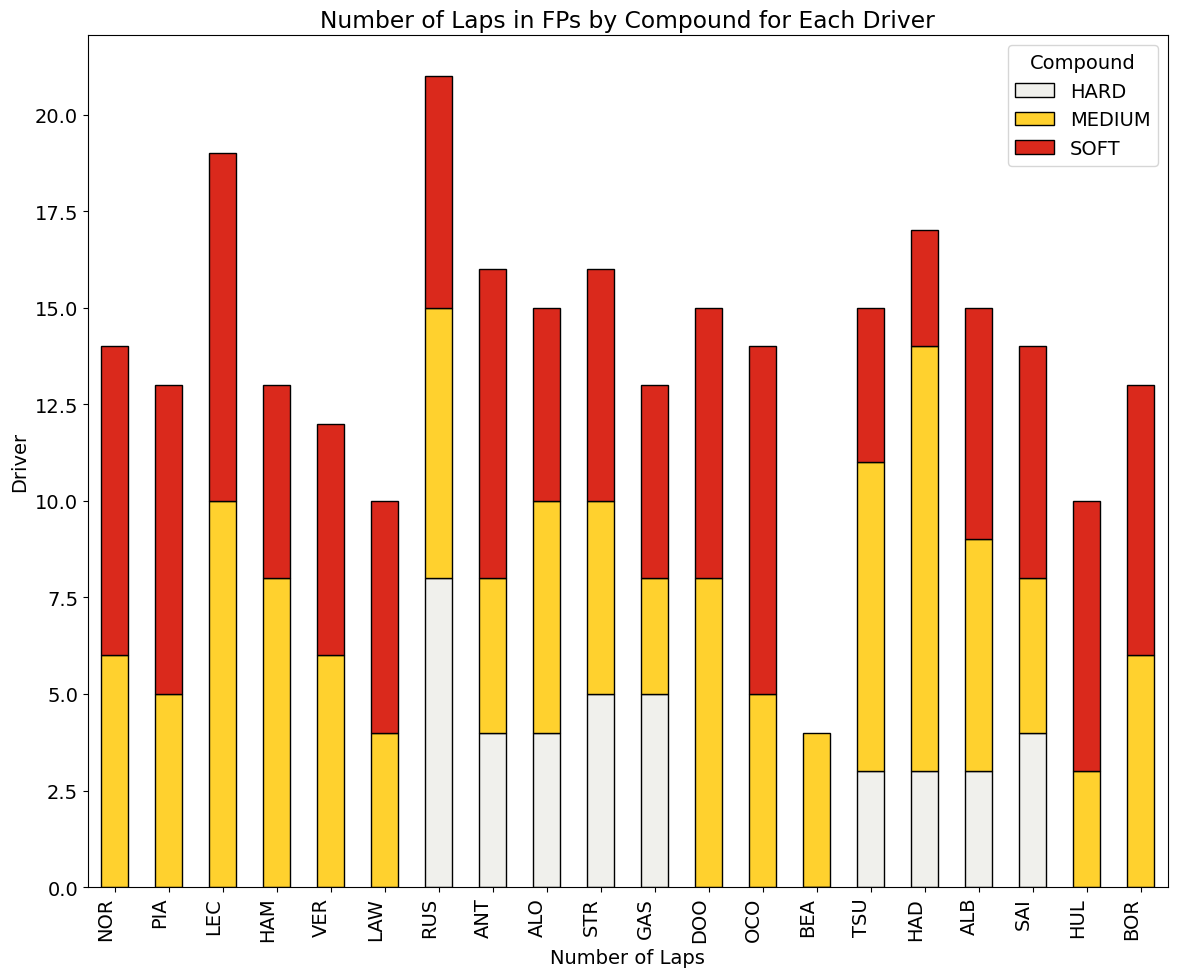

In [7]:
FP1_LAPS = FP1.laps.pick_quicklaps()
FP2_LAPS = FP2.laps.pick_quicklaps()
FP3_LAPS = FP3.laps.pick_quicklaps()

FP_LAPS = sqldf(
    """
SELECT *
FROM FP1_LAPS
UNION ALL
SELECT *
FROM FP2_LAPS
UNION ALL
SELECT *
FROM FP3_LAPS
"""
)

LAPS_BY_DRIVER = sqldf("SELECT Driver, Compound, COUNT(DISTINCT LapNumber) AS nrLaps FROM FP_LAPS GROUP BY Driver, Compound ORDER BY Driver, Compound")

DF_PIVOT = LAPS_BY_DRIVER.pivot_table(index='Driver', columns='Compound', values='nrLaps', aggfunc='sum', fill_value=0)
DRIVER_ORDER = ['NOR','PIA','LEC','HAM','VER','LAW','RUS','ANT','ALO','STR','GAS','DOO','OCO','BEA','TSU','HAD','ALB','SAI','HUL','BOR']
DF_PIVOT = DF_PIVOT.reindex(DRIVER_ORDER)
COLORS = [COMPOUND_COLORS.get(compound, '#333333') for compound in DF_PIVOT.columns]

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))
DF_PIVOT.plot(kind='bar', stacked=True, color=COLORS, edgecolor='black', ax=ax)

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Number of Laps")
ax.set_ylabel("Driver")
ax.set_title("Number of Laps in FPs by Compound for Each Driver")
ax.legend(title="Compound")
ax.set_xticks(range(len(DRIVER_ORDER)))
ax.set_xticklabels(DRIVER_ORDER, rotation=90, ha="right")

plt.tight_layout()
plt.show()

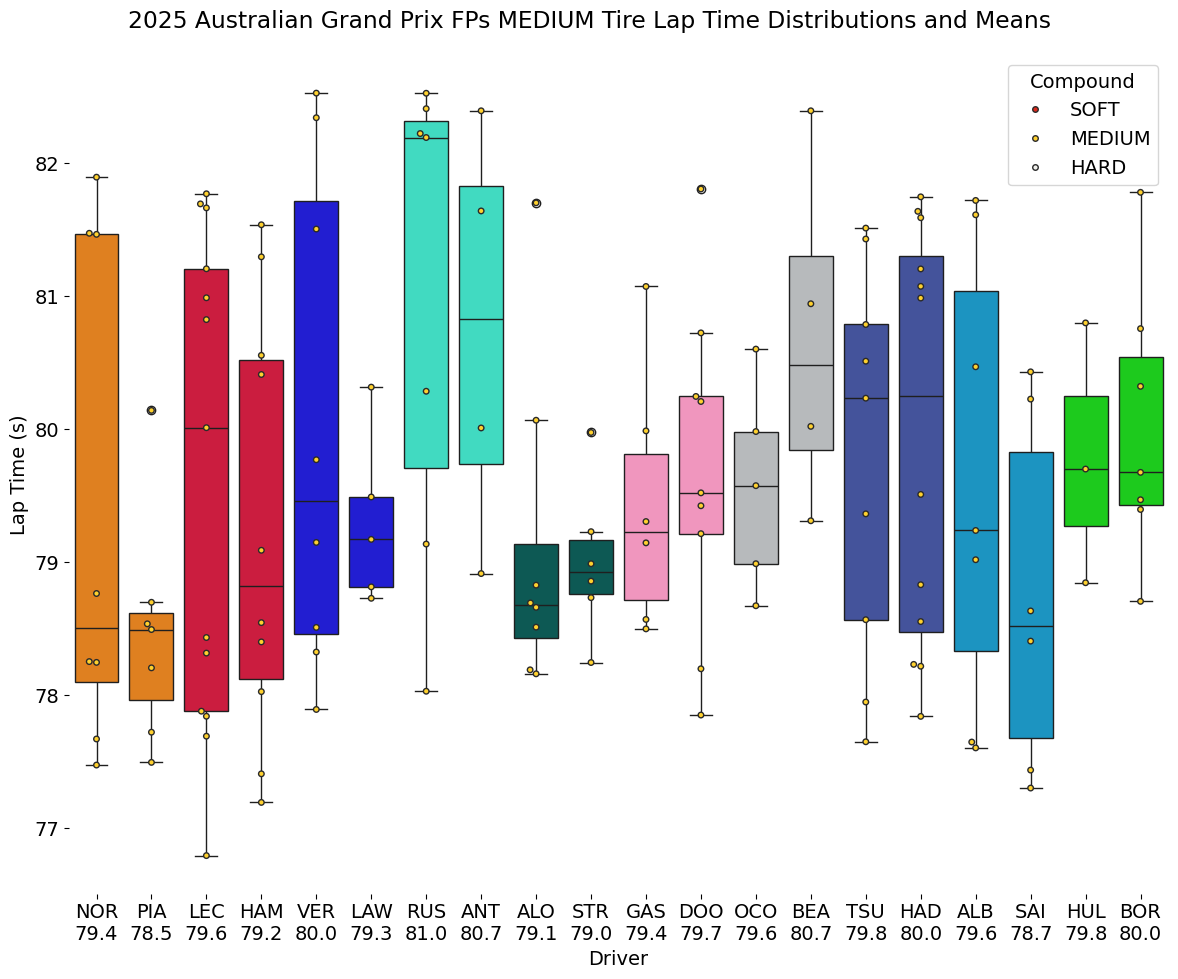

In [8]:
TYRE = "MEDIUM"

TIME_LAPS = sqldf(f"SELECT * FROM FP_LAPS WHERE Compound = '{TYRE}'")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

TIME_LAPS['LapTime'] = pd.to_timedelta(TIME_LAPS['LapTime'], errors='coerce')
TIME_LAPS["LapTime(s)"] = TIME_LAPS["LapTime"].dt.total_seconds()

sns.boxplot(data=TIME_LAPS,
            x="Driver",
            y="LapTime(s)",
            hue="Driver",
            order=['NOR','PIA','LEC','HAM','VER','LAW','RUS','ANT','ALO','STR','GAS','DOO','OCO','BEA','TSU','HAD','ALB','SAI','HUL','BOR'],
            palette=PALETTE_DRIVERS
            )

sns.swarmplot(data=TIME_LAPS,
              x="Driver",
              y="LapTime(s)",
              hue="Compound",
              palette=COMPOUND_COLORS,
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=1,
              size=4,
              )

MEANS = TIME_LAPS.groupby('Driver')["LapTime(s)"].mean().reindex(['NOR','PIA','LEC','HAM','VER','LAW','RUS','ANT','ALO','STR','GAS','DOO','OCO','BEA','TSU','HAD','ALB','SAI','HUL','BOR'])
ax.set_xticks(range(len(MEANS)))
ax.set_xticklabels([f"{driver}\n{mean:.1f}" for driver, mean in MEANS.items()])
ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
plt.suptitle("2025 " + str(RACE.event['EventName']) + f" FPs {TYRE} Tire Lap Time Distributions and Means")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

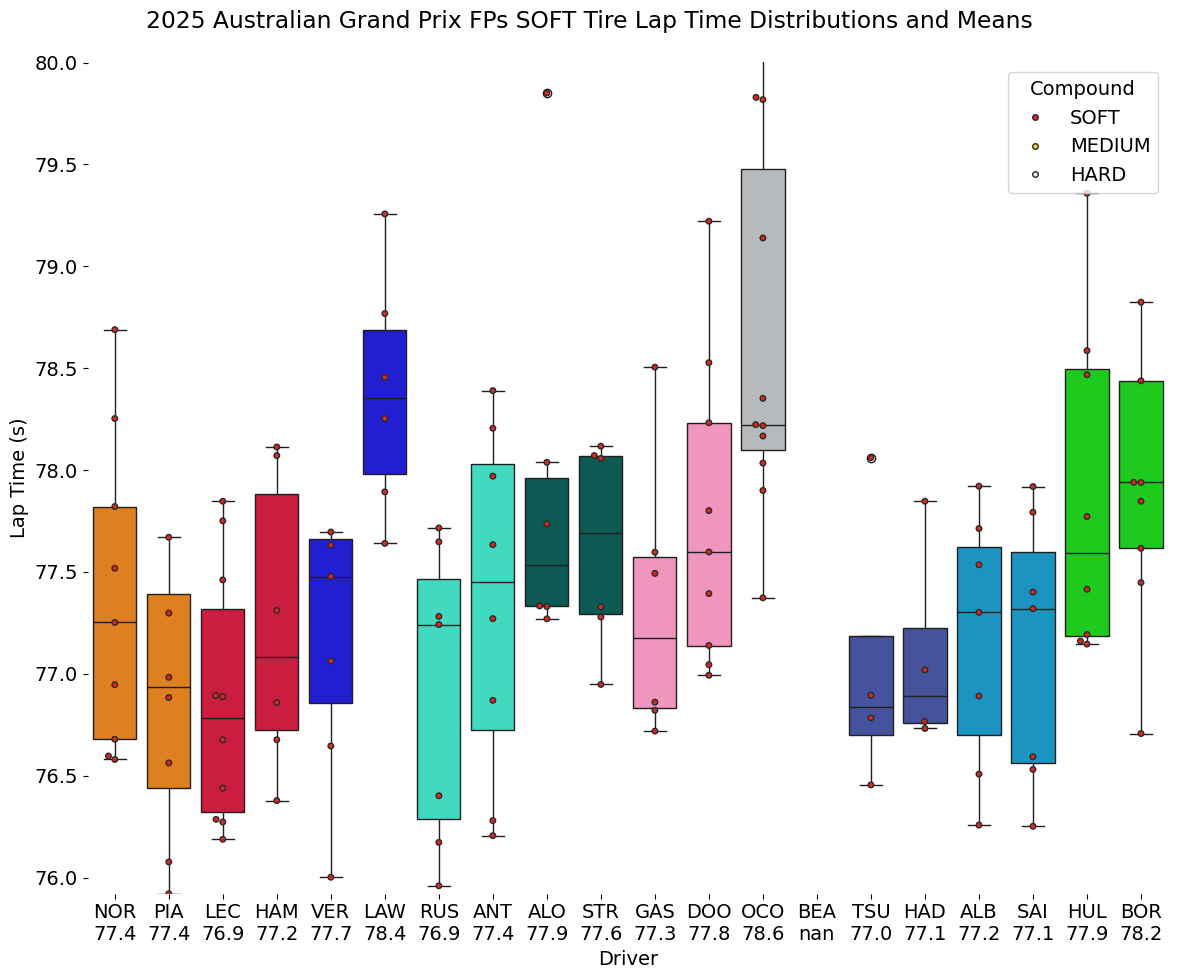

In [9]:
TYRE = "SOFT"

TIME_LAPS = sqldf(f"SELECT * FROM FP_LAPS WHERE Compound = '{TYRE}'")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

TIME_LAPS['LapTime'] = pd.to_timedelta(TIME_LAPS['LapTime'], errors='coerce')
TIME_LAPS["LapTime(s)"] = TIME_LAPS["LapTime"].dt.total_seconds()

sns.boxplot(data=TIME_LAPS,
            x="Driver",
            y="LapTime(s)",
            hue="Driver",
            order=['NOR','PIA','LEC','HAM','VER','LAW','RUS','ANT','ALO','STR','GAS','DOO','OCO','BEA','TSU','HAD','ALB','SAI','HUL','BOR'],
            palette=PALETTE_DRIVERS
            )

sns.swarmplot(data=TIME_LAPS,
              x="Driver",
              y="LapTime(s)",
              hue="Compound",
              palette=COMPOUND_COLORS,
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=1,
              size=4,
              )

MEANS = TIME_LAPS.groupby('Driver')["LapTime(s)"].mean().reindex(['NOR','PIA','LEC','HAM','VER','LAW','RUS','ANT','ALO','STR','GAS','DOO','OCO','BEA','TSU','HAD','ALB','SAI','HUL','BOR'])
ax.set_xticks(range(len(MEANS)))
ax.set_xticklabels([f"{driver}\n{mean:.1f}" for driver, mean in MEANS.items()])
ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
ax.set_ylim(TIME_LAPS["LapTime(s)"].min(), 80)
plt.suptitle("2025 " + str(RACE.event['EventName']) + f" FPs {TYRE} Tire Lap Time Distributions and Means")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# qualifying

In [10]:
Q = fastf1.get_session(SEASON, GP, 'Q')
Q.load()
results = SessionResults(DRIVERS)
results

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.4.4]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '1', '63', '22', '23', '16', '44', '10', '55', '6', '14', '18', '7', '5', '12', '27', '30', '31', 

,0
0,NOR
1,VER
2,RUS
3,ANT
4,ALB
5,STR
6,HUL
7,LEC
8,PIA
9,HAM


In [11]:
Q_RESULTS = Q.results
Q_RESULTS = Q_RESULTS[["Abbreviation", "Position", "Q1", "Q2", "Q3"]]
Q_RESULTS = sqldf(
    """
    SELECT "Abbreviation", "Position", CASE WHEN Position BETWEEN 1 AND 10 THEN Q3 WHEN Position BETWEEN 11 AND 15 THEN Q2 ELSE Q1 END AS Time
    FROM Q_RESULTS
    """
)
Q_RESULTS['Time'] = pd.to_timedelta(Q_RESULTS['Time'])
Q_RESULTS["LapTime"] = Q_RESULTS["Time"].dt.total_seconds()
Q_RESULTS['Position'] = Q_RESULTS['Position'].astype("int")
Q_RESULTS

,Abbreviation,Position,Time,LapTime
0,NOR,1,0 days 00:01:15.096000,75.096
1,PIA,2,0 days 00:01:15.180000,75.180
2,VER,3,0 days 00:01:15.481000,75.481
3,RUS,4,0 days 00:01:15.546000,75.546
4,TSU,5,0 days 00:01:15.670000,75.670
5,ALB,6,0 days 00:01:15.737000,75.737
6,LEC,7,0 days 00:01:15.755000,75.755
7,HAM,8,0 days 00:01:15.973000,75.973
8,GAS,9,0 days 00:01:15.980000,75.980
9,SAI,10,0 days 00:01:16.062000,76.062


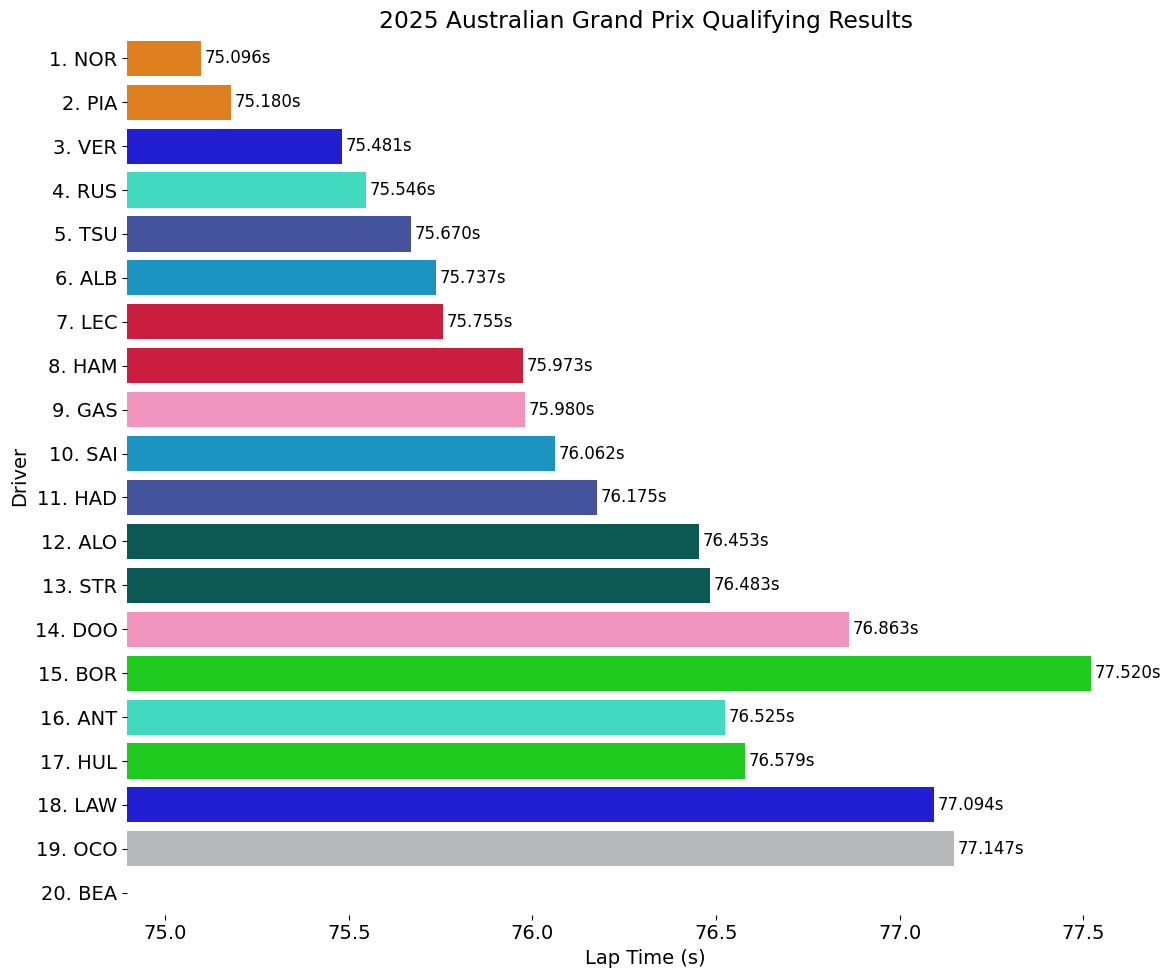

In [12]:
Q_RESULTS['Position_Abbreviation'] = Q_RESULTS['Position'].astype(str) + '. ' + Q_RESULTS['Abbreviation']

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

sns.barplot(data=Q_RESULTS,
            y='Position_Abbreviation', 
            x='LapTime',
            hue='Abbreviation', 
            dodge=False,
            palette=PALETTE_DRIVERS, 
            ax=ax
            )

for index, row in Q_RESULTS.iterrows():
    ax.text(row['LapTime'] + 0.01, index, f'{row["LapTime"]:.3f}s', va='center', fontsize=12)

ax.set_xlim(Q_RESULTS['LapTime'].min() - 0.2, Q_RESULTS['LapTime'].max() + 0.2)
ax.set_xlabel("Lap Time (s)")
ax.set_ylabel("Driver")
ax.set_title(f"2025 {RACE.event['EventName']} Qualifying Results")

sns.despine(left=True, bottom=True)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

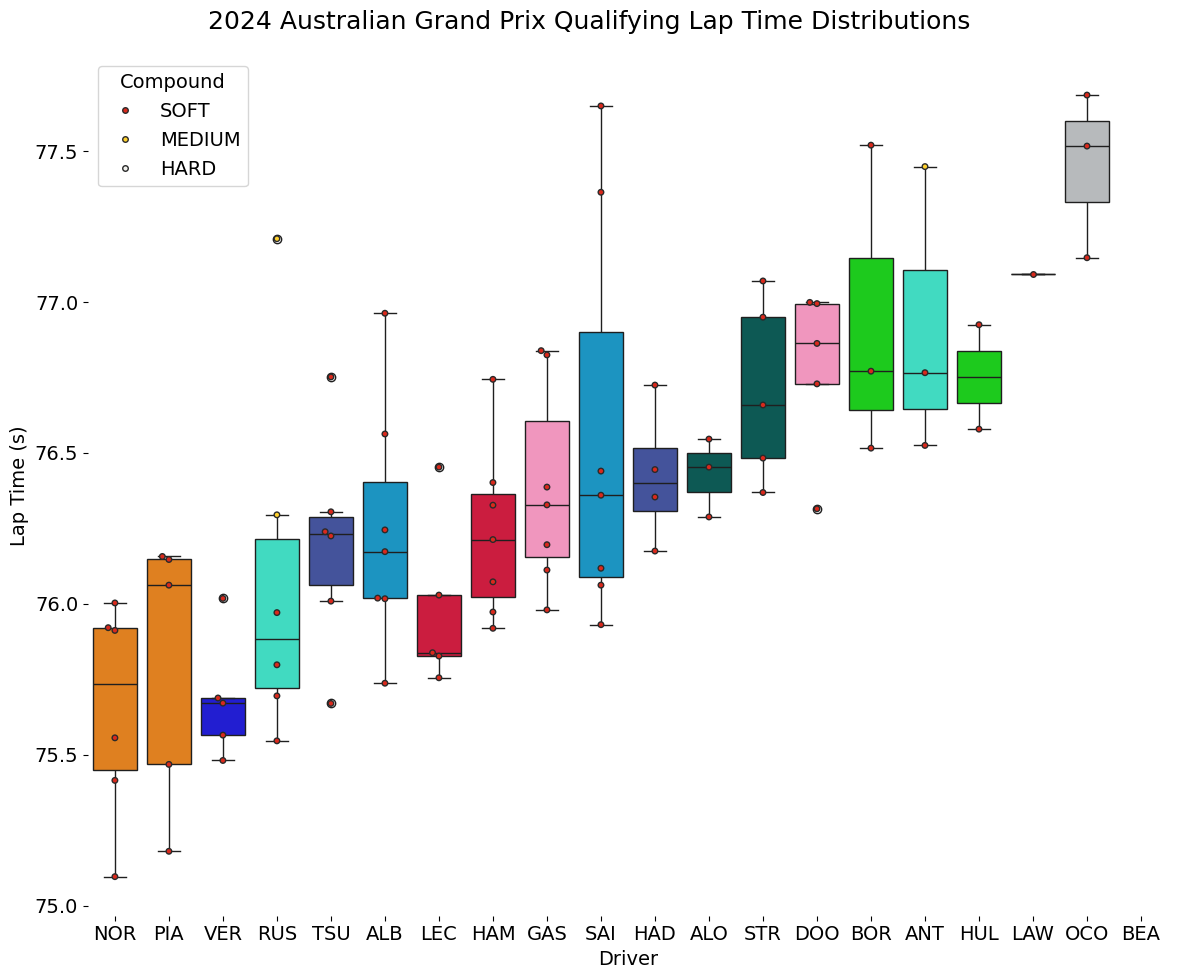

In [13]:
Q_LAPS = Q.laps.pick_quicklaps()
Q_LAPS["LapTime"] = pd.to_timedelta(Q_LAPS["LapTime"], errors="coerce")
Q_LAPS["LapTime"] = Q_LAPS["LapTime"].dt.total_seconds()

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

sns.boxplot(data=Q_LAPS,
            x="Driver",
            y="LapTime",
            hue="Driver",
            order=Q_RESULTS["Abbreviation"],
            palette=PALETTE_DRIVERS
            )

sns.swarmplot(data=Q_LAPS,
              x="Driver",   
              y="LapTime",
              hue="Compound",
              palette=COMPOUND_COLORS,
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=1,
              size=4,
              )

ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
plt.suptitle("2024 " + str(RACE.event['EventName']) + " Qualifying Lap Time Distributions", fontsize=18)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

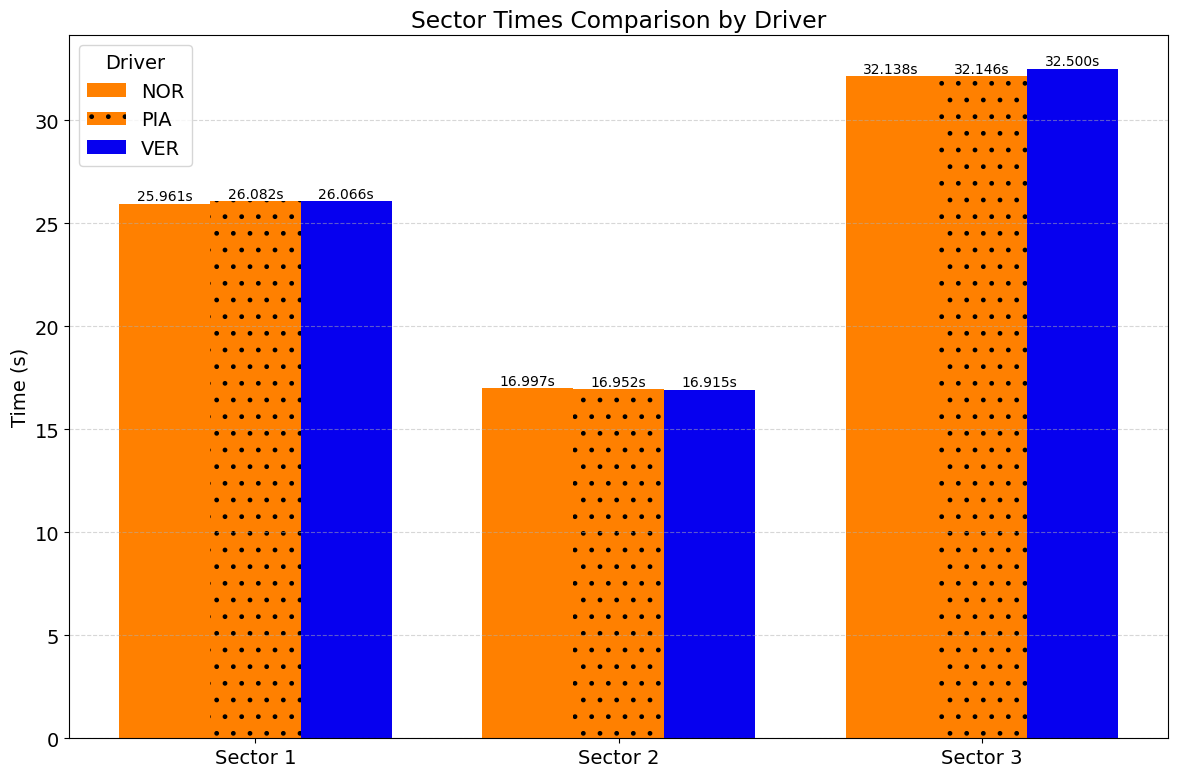

In [15]:
SECTOR_COMP = sqldf(
    """
    SELECT Q_LAPS.Driver, Q_LAPS.Sector1Time, Q_LAPS.Sector2Time, Q_LAPS.Sector3Time
    FROM Q_RESULTS
    JOIN Q_LAPS ON Q_RESULTS.Abbreviation = Q_LAPS.DRIVER AND Q_RESULTS.LapTime = Q_LAPS.LapTime
    """
)
SECTOR_COMP = sqldf("SELECT * FROM SECTOR_COMP WHERE Driver IN ('NOR', 'PIA', 'VER')")
SECTOR_COMP["Sector1Time"] = pd.to_timedelta(SECTOR_COMP["Sector1Time"], errors="coerce")
SECTOR_COMP["Sector2Time"] = pd.to_timedelta(SECTOR_COMP["Sector2Time"], errors="coerce")
SECTOR_COMP["Sector3Time"] = pd.to_timedelta(SECTOR_COMP["Sector3Time"], errors="coerce")

SECTOR_LONG = SECTOR_COMP.melt(id_vars='Driver',
                                value_vars=['Sector1Time', 'Sector2Time', 'Sector3Time'],
                                var_name='Sector',
                                value_name='Time'
                                )

SECTOR_LONG['Sector'] = SECTOR_LONG['Sector'].str.replace('Sector', 'Sector ', regex=False)
SECTOR_LONG['TimeSeconds'] = SECTOR_LONG['Time'].dt.total_seconds()

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 8))

SECTORS = ['Sector 1', 'Sector 2', 'Sector 3']
x = np.arange(len(SECTORS))
bar_width = 0.25

# Plot each driver's sector times
for i, driver in enumerate(SECTOR_LONG['Driver'].unique()):
    driver_data = SECTOR_LONG[SECTOR_LONG['Driver'] == driver].sort_values('Sector')
    times = driver_data['TimeSeconds'].values
    bars = ax.bar(x + i * bar_width,
           times,
           width=bar_width,
           label=driver,
           color=PALETTE_DRIVERS[driver],
           hatch='.' if DRIVER_STYLES[driver] == 'dashed' else ''
           )
    for j, time in enumerate(times):
        ax.text(x[j] + i * bar_width,
                time + 0.02,
                f'{time:.3f}s',
                ha='center',
                va='bottom',
                fontsize=10)

# Ticks and labels
ax.set_xticks(x + bar_width)
ax.set_xticklabels(SECTORS)
ax.set_ylabel("Time (s)")
ax.set_title("Sector Times Comparison by Driver")
ax.legend(title="Driver")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [85]:
DRIVER_STYLES["VER"]

'solid'

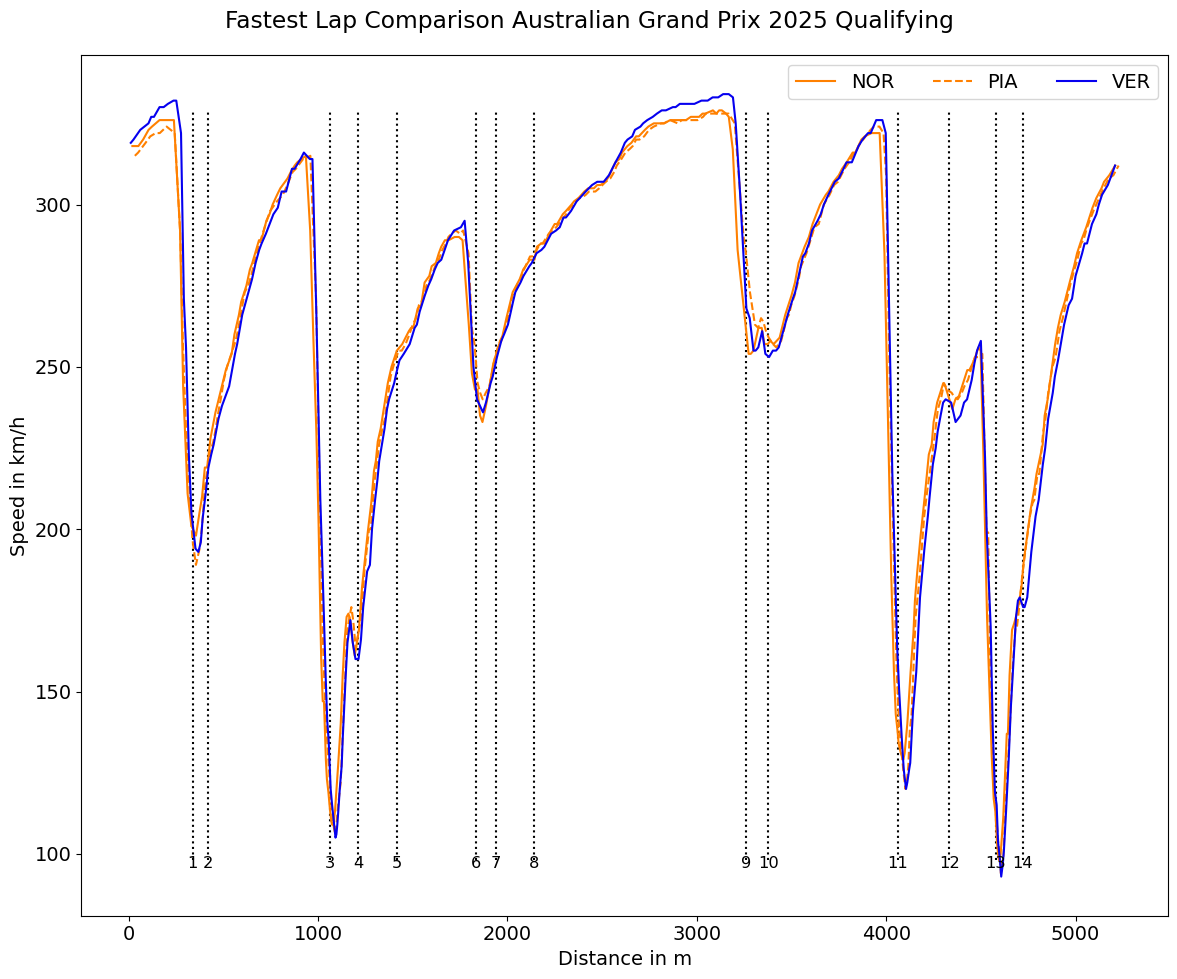

In [ ]:
CIRCUIT_INFO = Q.get_circuit_info()

NOR_LAP = Q_LAPS.pick_driver("NOR").pick_fastest()
NOR_TEL = NOR_LAP.get_car_data().add_distance()
NOR_TEL["Time"] = pd.to_timedelta(NOR_TEL["Time"], errors="coerce")
PIA_LAP = Q_LAPS.pick_driver("PIA").pick_fastest()
PIA_TEL = PIA_LAP.get_car_data().add_distance()
PIA_TEL["Time"] = pd.to_timedelta(PIA_TEL["Time"], errors="coerce")
VER_LAP = Q_LAPS.pick_driver("VER").pick_fastest()
VER_TEL = VER_LAP.get_car_data().add_distance()
VER_TEL["Time"] = pd.to_timedelta(VER_TEL["Time"], errors="coerce")
RUS_LAP = Q_LAPS.pick_driver("RUS").pick_fastest()
RUS_TEL = RUS_LAP.get_car_data().add_distance()
RUS_TEL["Time"] = pd.to_timedelta(RUS_TEL["Time"], errors="coerce")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

ax.vlines(
    x=CIRCUIT_INFO.corners['Distance'], 
    ymin=NOR_TEL["Speed"].min(), 
    ymax=NOR_TEL["Speed"].max(), 
    linestyles='dotted', 
    colors='black'
    )

for _, corner in CIRCUIT_INFO.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    ax.text(
        corner['Distance'], 
        NOR_TEL['Speed'].min() - 0.5,
        txt, va='center_baseline', ha='center', size='small'
    )

ax.plot(NOR_TEL['Distance'], NOR_TEL['Speed'], color=PALETTE_TEAMS["McLaren"], linestyle=DRIVER_STYLES["NOR"], label='NOR')
ax.plot(PIA_TEL['Distance'], PIA_TEL['Speed'], color=PALETTE_TEAMS["McLaren"], linestyle=DRIVER_STYLES["PIA"], label='PIA')
ax.plot(VER_TEL['Distance'], VER_TEL['Speed'], color=PALETTE_TEAMS["Red Bull"], linestyle=DRIVER_STYLES["VER"], label='VER')

ax.set_xlabel('Distance in m')
ax.set_ylabel('Speed in km/h')

fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax.transAxes, ncol=6)

plt.suptitle(f"Fastest Lap Comparison " f"{Q.event['EventName']} {Q.event.year} Qualifying")

plt.tight_layout()
plt.show()

# race

In [23]:
RACE_LAPS["LapNumber"].min()

np.float64(31.0)

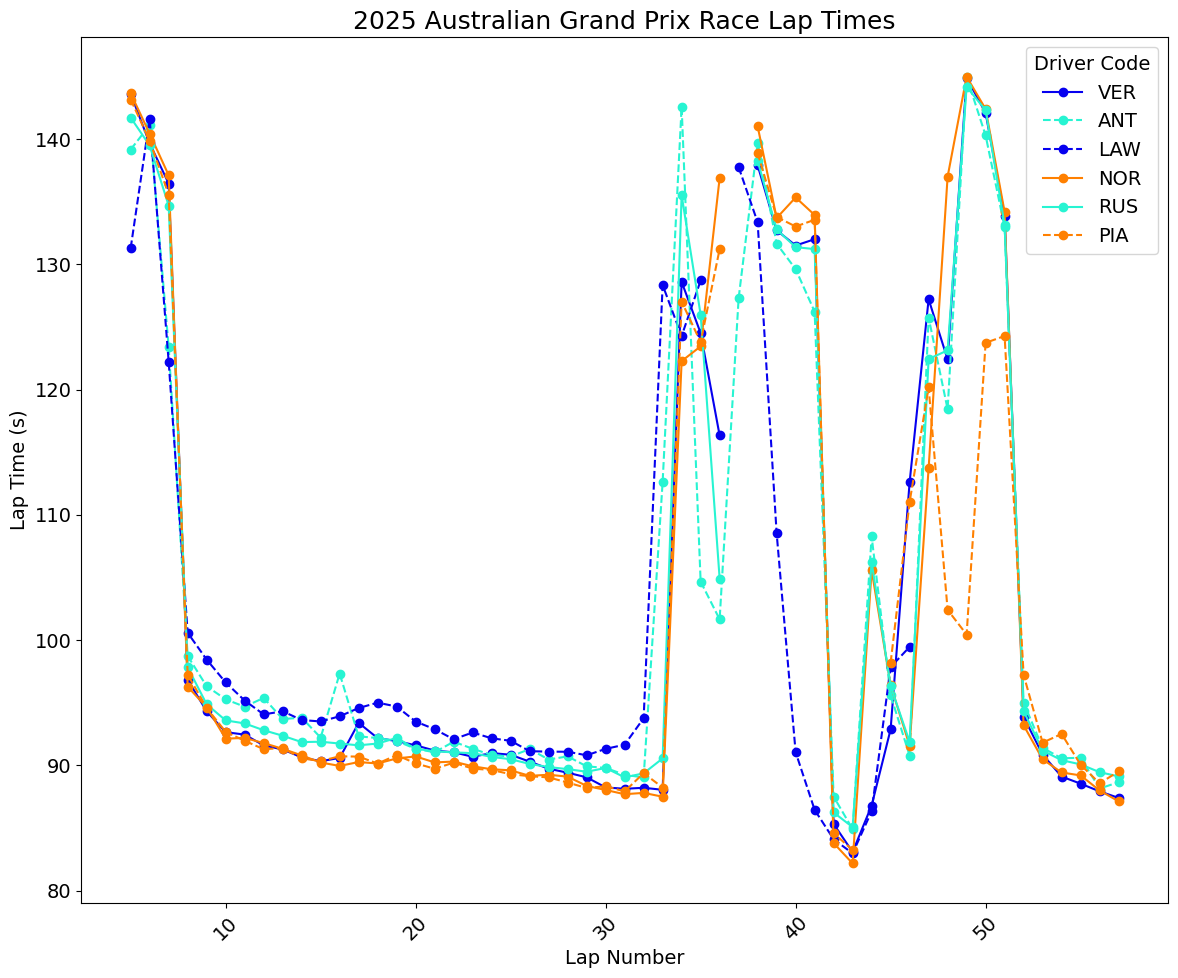

In [26]:
# RACE_LAPS = RACE.laps.pick_quicklaps()
RACE_LAPS = RACE.laps
RACE_LAPS["LapTime"] = pd.to_timedelta(RACE_LAPS["LapTime"], errors="coerce")
RACE_LAPS["lapTimeSeconds"] = RACE_LAPS["LapTime"].dt.total_seconds()
race_laps = sqldf("SELECT * FROM RACE_LAPS WHERE Driver IN ('NOR', 'PIA', 'VER', 'LAW', 'RUS', 'ANT')")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for driver in race_laps['Driver'].unique():
    driver_data = race_laps[race_laps['Driver'] == driver]
    color = PALETTE_DRIVERS[driver]
    style = DRIVER_STYLES[driver]

    ax.plot(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        label=driver,
        color=color, 
        linestyle=style
        , marker='o'
        )

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time (s)")
ax.set_title("2025 " + str(RACE.event['EventName']) + " Race Lap Times", fontsize=18)
ax.legend(title="Driver Code")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [29]:
AVERAGE_PACE

Driver
ALB    104.153094
ALO     97.136643
ANT    103.866679
BEA    102.994250
BOR    101.620450
DOO           NaN
GAS    104.337415
HAD           NaN
HAM    103.411115
HUL    104.051849
LAW    100.605146
LEC    103.461481
NOR    103.165404
OCO    103.042538
PIA    101.717353
RUS    103.283308
SAI           NaN
STR    104.074377
TSU    103.574750
VER    103.032481
Name: lapTimeSeconds, dtype: float64

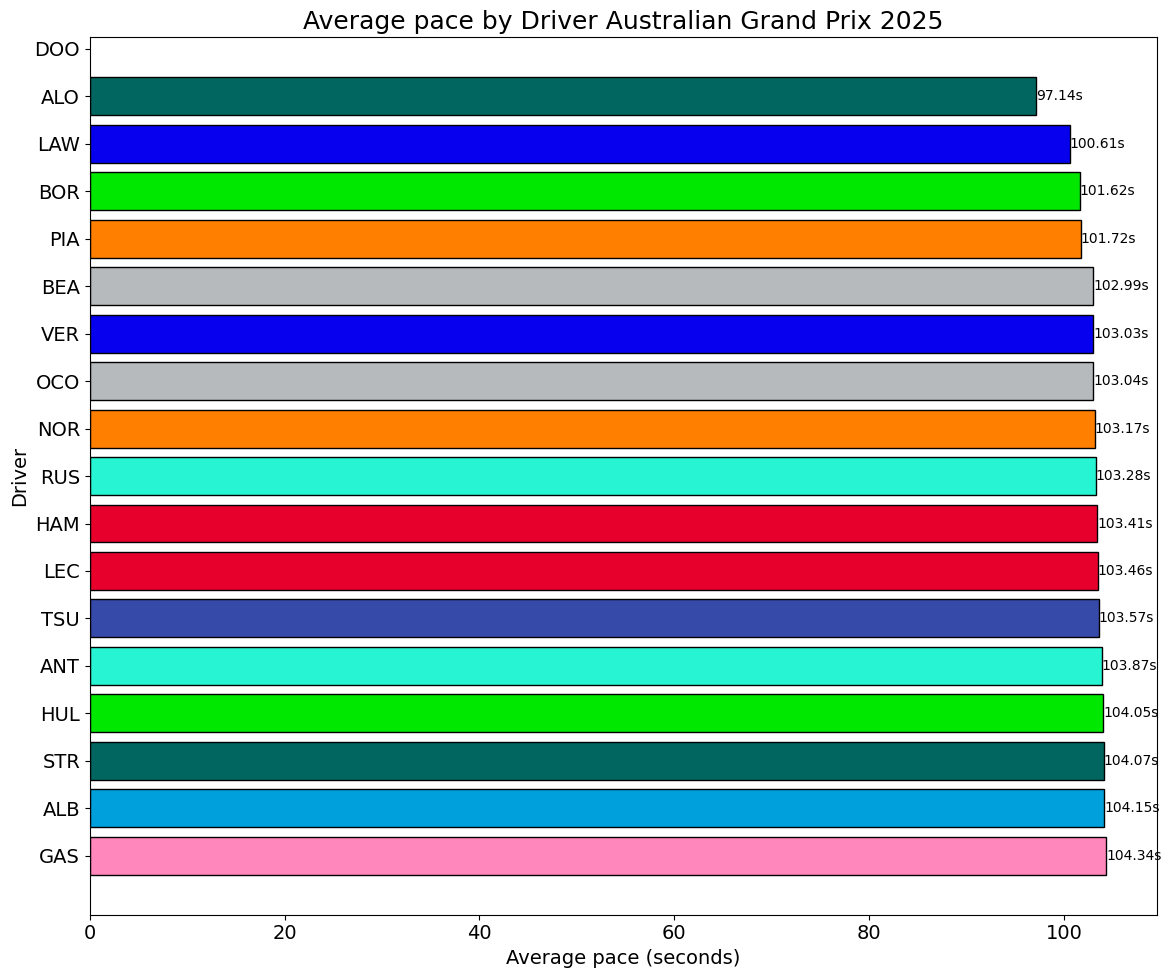

In [32]:
AVERAGE_PACE = RACE_LAPS.groupby("Driver")["lapTimeSeconds"].mean().reset_index()
AVERAGE_PACE = AVERAGE_PACE.rename(columns={"lapTimeSeconds": "avgPace"})
AVERAGE_PACE = AVERAGE_PACE.sort_values("avgPace", ascending=False)

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(
    AVERAGE_PACE['Driver'],
    AVERAGE_PACE['avgPace'],
    color=[PALETTE_DRIVERS[driver] for driver in AVERAGE_PACE['Driver']],
    edgecolor='black'
)

# ax.set_xlim(88.5, 89.5)

for index, (driver, min_time) in enumerate(zip(AVERAGE_PACE['Driver'], AVERAGE_PACE['avgPace'])):
    ax.text(min_time, index, f"{min_time:.2f}s", va='center', ha='left', color='black', fontsize=10)

ax.set_xlabel('Average pace (seconds)')
ax.set_ylabel('Driver')
ax.set_title('Average pace by Driver ' + str(RACE.event['EventName'] + ' 2025'), fontsize=18)

plt.tight_layout()
plt.show()

# championship races after the race

In [33]:
URL = f"http://api.jolpi.ca/ergast/f1/{SEASON}/{ROUND_NUMBER}/results.json"
response = requests.get(URL)
data = response.json()
race_results = data['MRData']['RaceTable']['Races'][0]['Results']
df = pd.json_normalize(race_results)
df.columns

Index(['number', 'position', 'positionText', 'points', 'grid', 'laps',
       'status', 'Driver.driverId', 'Driver.permanentNumber', 'Driver.code',
       'Driver.url', 'Driver.givenName', 'Driver.familyName',
       'Driver.dateOfBirth', 'Driver.nationality', 'Constructor.constructorId',
       'Constructor.url', 'Constructor.name', 'Constructor.nationality',
       'Time.millis', 'Time.time', 'FastestLap.rank', 'FastestLap.lap',
       'FastestLap.Time.time'],
      dtype='object')

In [34]:
RESULTS = []

ROUNDS = range(1, 24, 1)

for RND in ROUNDS:
    URL = f"http://api.jolpi.ca/ergast/f1/{SEASON}/{RND}/results.json"
    RESPONSE = response.json()
    RACE_RESULTS = data['MRData']['RaceTable']['Races'][0]['Results']
    TEMP = pd.json_normalize(RACE_RESULTS)
    TEMP['ROUND'] = RND
    TEMP = TEMP[['ROUND', 'Driver.code', 'Constructor.name', 'points']]
    RESULTS.append(TEMP)

RESULTS = pd.concat(RESULTS)
RESULTS = pd.DataFrame(RESULTS)
RESULTS.columns =['ROUND', 'DRIVER_CODE', 'CONSTRUCTOR_NAME', 'POINTS']
RESULTS = sqldf(
    """ 
    SELECT R.*, GP.GRAND_PRIX_NAME
    FROM RESULTS R
    JOIN GRAND_PRIXS GP ON R.ROUND = GP.ROUND
    """
)
RESULTS['POINTS'] = pd.to_numeric(RESULTS['POINTS'], errors='coerce')
RESULTS

,ROUND,DRIVER_CODE,CONSTRUCTOR_NAME,POINTS,GRAND_PRIX_NAME
0,1,NOR,McLaren,25,Bahrain
1,1,VER,Red Bull,18,Bahrain
2,1,RUS,Mercedes,15,Bahrain
3,1,ANT,Mercedes,12,Bahrain
4,1,ALB,Williams,10,Bahrain
...,...,...,...,...,...
455,23,BOR,Sauber,0,Qatar
456,23,ALO,Aston Martin,0,Qatar
457,23,SAI,Williams,0,Qatar
458,23,DOO,Alpine F1 Team,0,Qatar


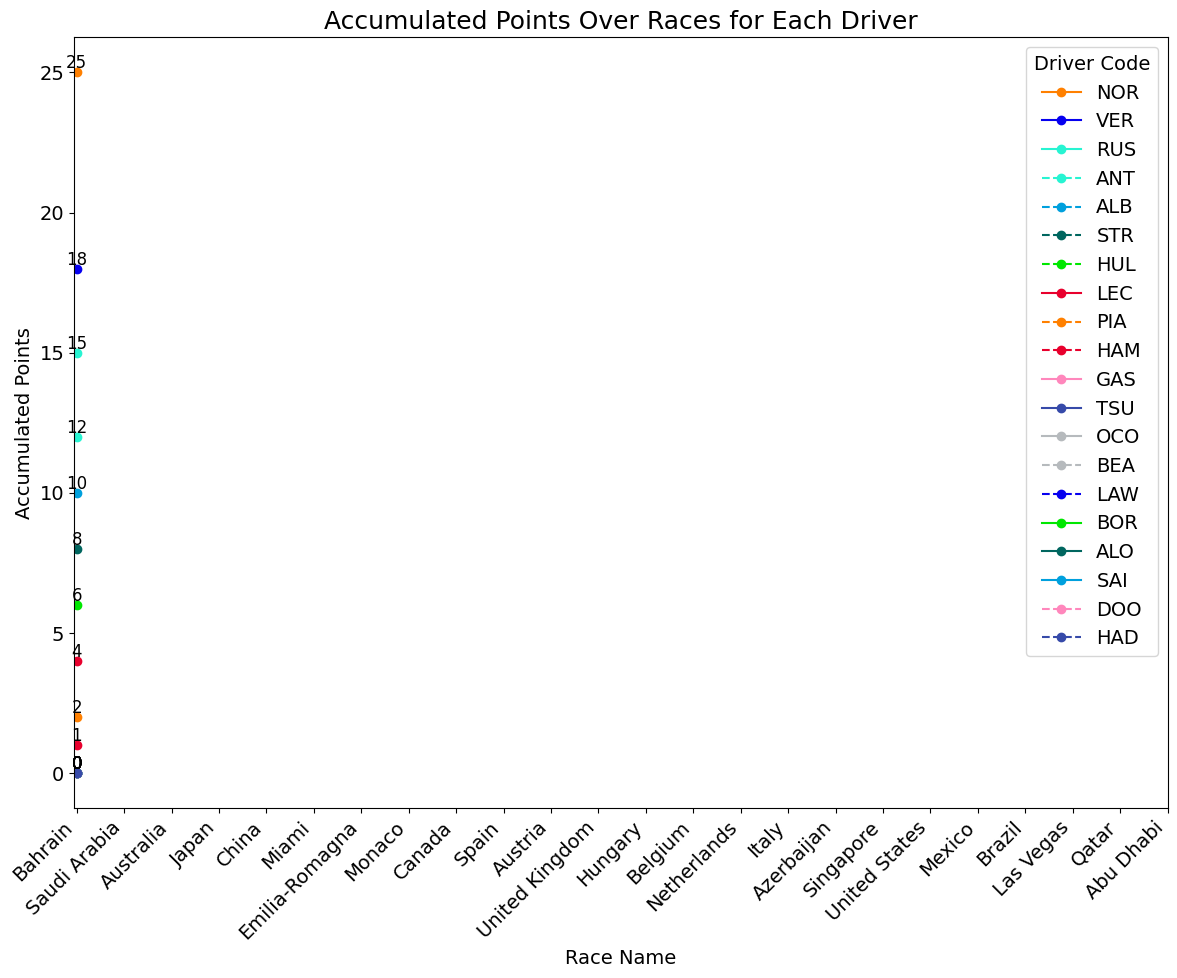

In [35]:
plt.style.use("default")
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for DRIVER in DRIVERS:
    DRIVER_DATA = RESULTS[RESULTS['DRIVER_CODE'] == DRIVER]
    DRIVER_FIRST_RACE = DRIVER_DATA[DRIVER_DATA['ROUND'] <= 1]

    ax.plot(DRIVER_FIRST_RACE['GRAND_PRIX_NAME'], DRIVER_FIRST_RACE['POINTS'], 
            label=DRIVER, 
            color=PALETTE_DRIVERS.get(DRIVER), 
            linestyle=DRIVER_STYLES.get(DRIVER), 
            marker='o')

    for x, y in zip(DRIVER_FIRST_RACE['GRAND_PRIX_NAME'], DRIVER_FIRST_RACE['POINTS']):
        ax.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=12)

ax.set_xticks(range(len(GRAND_PRIXS["GRAND_PRIX_NAME"])))
ax.set_xticklabels(GRAND_PRIXS["GRAND_PRIX_NAME"], rotation=45, ha="right")

ax.set_xlabel("Race Name")
ax.set_ylabel("Accumulated Points")
ax.set_title("Accumulated Points Over Races for Each Driver", fontsize=18)
ax.legend(title="Driver Code")

plt.tight_layout()
plt.show()

In [36]:
RESULTS_TEAMS = sqldf(
    """
    SELECT ROUND, CONSTRUCTOR_NAME, GRAND_PRIX_NAME, sum(POINTS) AS POINTS
    FROM RESULTS
    GROUP BY ROUND, CONSTRUCTOR_NAME, GRAND_PRIX_NAME
    """
    )
RESULTS_TEAMS

,ROUND,CONSTRUCTOR_NAME,GRAND_PRIX_NAME,POINTS
0,1,Alpine F1 Team,Bahrain,0
1,1,Aston Martin,Bahrain,8
2,1,Ferrari,Bahrain,5
3,1,Haas F1 Team,Bahrain,0
4,1,McLaren,Bahrain,27
...,...,...,...,...
225,23,Mercedes,Qatar,27
226,23,RB F1 Team,Qatar,0
227,23,Red Bull,Qatar,18
228,23,Sauber,Qatar,6


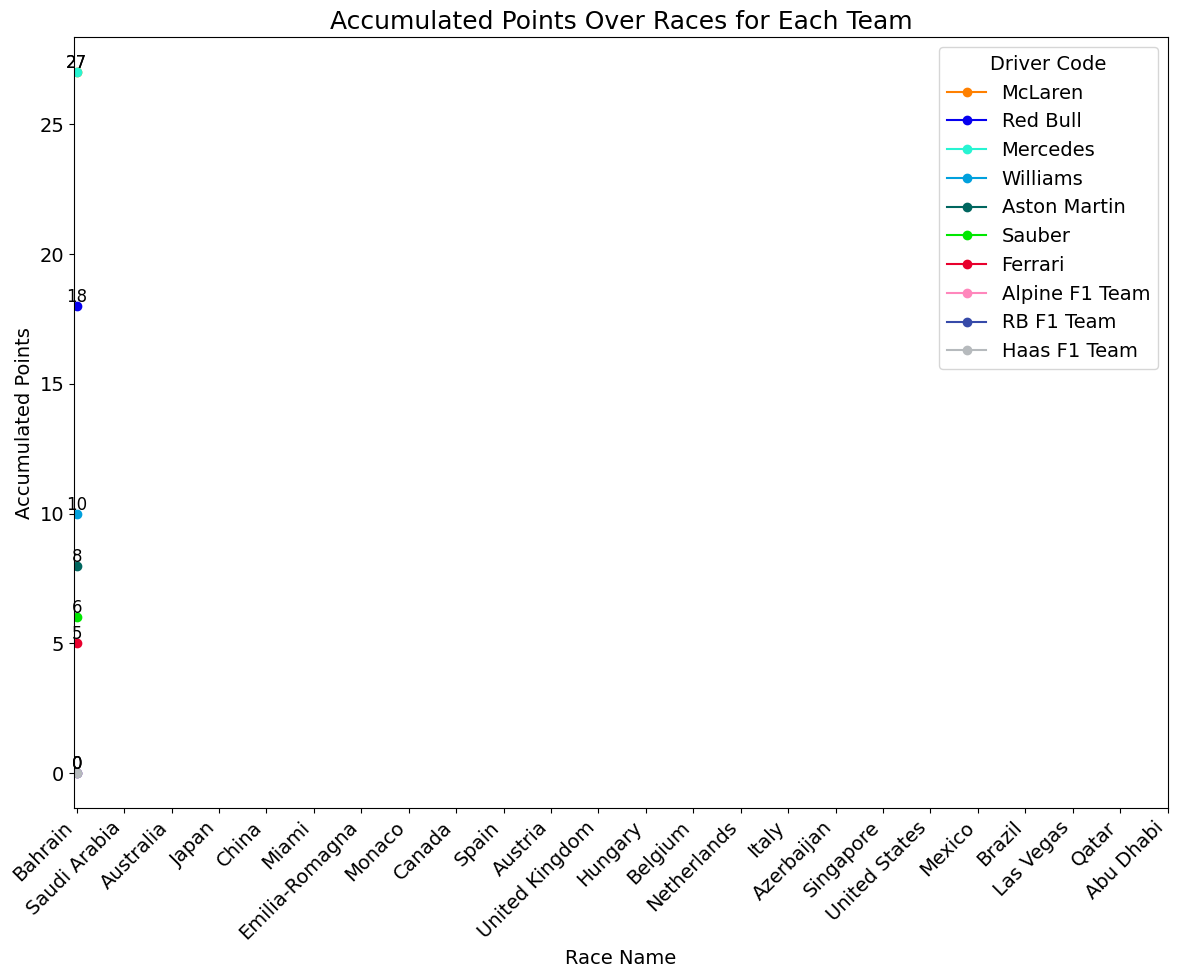

In [37]:
plt.style.use("default")
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for TEAM in TEAMS:
    TEAM_DATA = RESULTS_TEAMS[RESULTS_TEAMS['CONSTRUCTOR_NAME'] == TEAM]
    TEAM_FIRST_RACE = TEAM_DATA[TEAM_DATA['ROUND'] <= 1]

    ax.plot(TEAM_FIRST_RACE['GRAND_PRIX_NAME'], TEAM_FIRST_RACE['POINTS'], 
            label=TEAM, 
            color=PALETTE_TEAMS.get(TEAM),
            marker='o')

    for x, y in zip(TEAM_FIRST_RACE['GRAND_PRIX_NAME'], TEAM_FIRST_RACE['POINTS']):
        ax.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=12)

ax.set_xticks(range(len(GRAND_PRIXS["GRAND_PRIX_NAME"])))
ax.set_xticklabels(GRAND_PRIXS["GRAND_PRIX_NAME"], rotation=45, ha="right")
ax.set_xlabel("Race Name")
ax.set_ylabel("Accumulated Points")
ax.set_title("Accumulated Points Over Races for Each Team", fontsize=18)
ax.legend(title="Driver Code")

plt.tight_layout()
plt.show()